# Урок 1.3. Производная, градиент и градиентный спуск

**Интерактивная версия:** `lessons/lesson_1_3/web/index.html`

После урока вы сможете:
- объяснить производную как предел наклона секущей и проверить её конечными разностями;
- выполнить градиентный спуск руками и объяснить роль темпа через множитель $1 - \eta a$;
- посчитать градиент функции двух параметров и понять, зачем нормируют признаки;
- объяснить шаг Ньютона $-f'/f''$ и градиентный бустинг как спуск по прогнозам.

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "shared" / "python" / "gbcourse").is_dir())
sys.path.insert(0, str(ROOT / "shared" / "python"))

import matplotlib.pyplot as plt
import numpy as np

from gbcourse import GBRegressor, datasets, style
from gbcourse.metrics import mse
from gbcourse.plotting import use_course_style

use_course_style()

## 1. Производная — предел наклона секущей

Для $f(\theta) = \theta^2$ в точке 3 наклон секущей $(f(3 + \varepsilon) - f(3))/\varepsilon = 6 + \varepsilon \to 6$.

In [2]:
f = lambda t: t**2  # noqa: E731
for eps in (1, 0.1, 0.01, 0.001):
    print(f"ε = {eps:<6}: наклон секущей = {(f(3 + eps) - f(3)) / eps:.4f}")

ε = 1     : наклон секущей = 7.0000
ε = 0.1   : наклон секущей = 6.1000
ε = 0.01  : наклон секущей = 6.0100
ε = 0.001 : наклон секущей = 6.0010


## 2. Производные потерь и численная проверка

По цепному правилу $\partial_F \tfrac12 (y - F)^2 = -(y - F)$. Для константы $c$ под ½·MSE шести квартир
$f'(c) = c - \bar y$. Проверим конечными разностями.

In [3]:
y = np.array([3, 5, 4, 8, 9, 13.0])
fc = lambda c: np.mean(0.5 * (y - c) ** 2)  # noqa: E731
dfc = lambda c: c - y.mean()  # noqa: E731
for c in (0.0, 2.0, 7.0):
    num = (fc(c + 1e-5) - fc(c - 1e-5)) / 2e-5
    print(f"c = {c}: формула {dfc(c):+.6f}, конечные разности {num:+.6f}")

c = 0.0: формула -7.000000, конечные разности -7.000000
c = 2.0: формула -5.000000, конечные разности -5.000000
c = 7.0: формула +0.000000, конечные разности +0.000000


## 3. Спуск руками: константа для шести квартир

$c_{k+1} = c_k - \eta f'(c_k) = c_k + \eta(\bar y - c_k)$ — тот же «бустинг одного числа» из урока 1.

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


η = 0.5: [0.     3.5    5.25   6.125  6.5625]


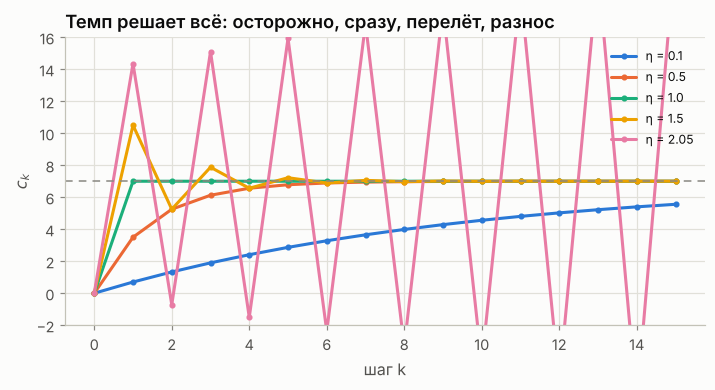

In [4]:
fig, ax = plt.subplots(figsize=(7.5, 3.4))
for eta, color in zip((0.1, 0.5, 1.0, 1.5, 2.05), style.SERIES):
    c, path = 0.0, [0.0]
    for _ in range(15):
        c = c - eta * dfc(c)
        path.append(c)
    ax.plot(path, marker="o", ms=3, color=color, label=f"η = {eta}")
    if eta == 0.5:
        print("η = 0.5:", np.round(path[:5], 4))
ax.axhline(7, color=style.MUTED, ls=(0, (5, 4)), lw=1)
ax.set(xlabel="шаг k", ylabel="$c_k$", ylim=(-2, 16), title="Темп решает всё: осторожно, сразу, перелёт, разнос")
ax.legend(fontsize=8)
plt.show()

## 4. Карта темпа для параболы $\tfrac a2\theta^2$

Множитель $1 - \eta a$: сходимость при $0 < \eta < 2/a$, наилучший темп $1/a$.

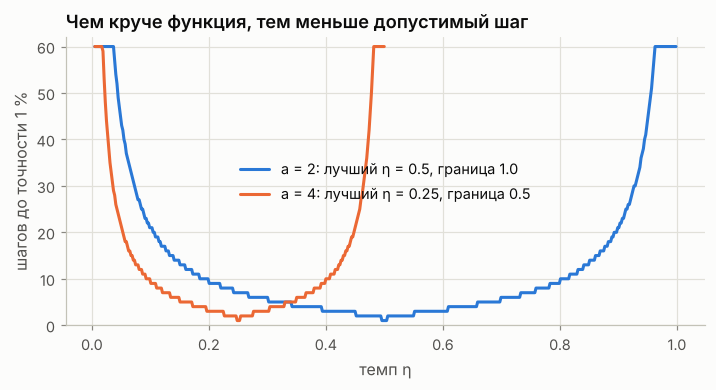

In [5]:
etas = np.linspace(0.005, 1.2, 600)
fig, ax = plt.subplots(figsize=(7.5, 3.4))
for a, color in zip((2, 4), style.SERIES):
    k = np.abs(1 - etas * a)
    steps = np.where(k < 1, np.ceil(np.log(0.01) / np.log(np.maximum(k, 1e-12))), np.nan)
    ax.plot(etas, np.minimum(steps, 60), color=color, label=f"a = {a}: лучший η = {1 / a}, граница {2 / a}")
ax.set(xlabel="темп η", ylabel="шагов до точности 1 %", ylim=(0, 62), title="Чем круче функция, тем меньше допустимый шаг")
ax.legend()
plt.show()

## 5. Неудобные функции: плоское дно, излом, несколько минимумов

In [6]:
funcs = {
    "θ⁴/4 (плоское дно)": (lambda t: t**4 / 4, lambda t: t**3),
    "|θ| (излом)": (np.abs, np.sign),
    "1.5θ² + sin 3θ (волна)": (lambda t: 1.5 * t**2 + np.sin(3 * t), lambda t: 3 * t + 3 * np.cos(3 * t)),
}
for name, (fn, dfn) in funcs.items():
    for t0 in (2.5, -2.5):
        t = t0
        for _ in range(60):
            t -= 0.1 * dfn(t)
        print(f"{name:24s} старт {t0:+.1f}: θ = {t:+.4f}, f = {fn(t):.4f}")

θ⁴/4 (плоское дно)       старт +2.5: θ = +0.2740, f = 0.0014
θ⁴/4 (плоское дно)       старт -2.5: θ = -0.2740, f = 0.0014
|θ| (излом)              старт +2.5: θ = +0.1000, f = 0.1000
|θ| (излом)              старт -2.5: θ = -0.1000, f = 0.1000
1.5θ² + sin 3θ (волна)   старт +2.5: θ = +0.9794, f = 1.6408
1.5θ² + sin 3θ (волна)   старт -2.5: θ = -0.3900, f = -0.6926


## 6. Градиент двух параметров и стандартизация

Прямая $a x + b$ для шести квартир. Наклон по $a$ в 60 с лишним раз круче, чем по $b$: общий темп не подходит
обоим направлениям. После стандартизации $z = (x - \bar x)/s_x$ кривизны равны, и спуск с $\eta = 1$ приходит
в минимум за один шаг.

градиент в (0, 0): -440.0 -7.0
сырые площади, 5000 шагов: a = 0.1437, b = -0.6635
стандартизованные, 1 шаг: a = 0.1886, b = -3.3714
МНК: [ 0.18857143 -3.37142857]


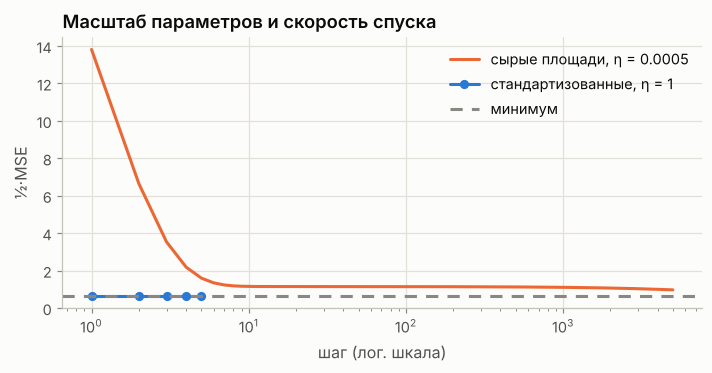

In [7]:
x = np.array([30, 40, 50, 60, 70, 80.0])


def fit_line(x, y, eta, steps):
    a = b = 0.0
    path = []
    for _ in range(steps):
        r = y - (a * x + b)
        a, b = a + eta * np.mean(r * x), b + eta * np.mean(r)
        path.append(np.mean((y - a * x - b) ** 2) / 2)
    return a, b, path


print("градиент в (0, 0):", -np.mean(x * y), -np.mean(y))
a_raw, b_raw, path_raw = fit_line(x, y, 5e-4, 5000)
z = (x - x.mean()) / x.std()
a_z, b_z, path_z = fit_line(z, y, 1.0, 5)
print(f"сырые площади, 5000 шагов: a = {a_raw:.4f}, b = {b_raw:.4f}")
print(f"стандартизованные, 1 шаг: a = {a_z / x.std():.4f}, b = {b_z - a_z * x.mean() / x.std():.4f}")
print("МНК:", np.polyfit(x, y, 1))
fig, ax = plt.subplots(figsize=(7.5, 3.2))
ax.semilogx(range(1, 5001), path_raw, color=style.ORANGE, label="сырые площади, η = 0.0005")
ax.semilogx(range(1, 6), path_z, marker="o", color=style.BLUE, label="стандартизованные, η = 1")
ax.axhline(np.mean((y - np.polyval(np.polyfit(x, y, 1), x)) ** 2) / 2, color=style.MUTED, ls=(0, (4, 3)), label="минимум")
ax.set(xlabel="шаг (лог. шкала)", ylabel="½·MSE", title="Масштаб параметров и скорость спуска")
ax.legend()
plt.show()

## 7. Шаг Ньютона на log-loss константы

3 из 10 клиентов не вернули кредит. Минимум log-loss по логиту — $\ln(0.3/0.7)$.

спуск η = 1 : [0.64729786 0.49713186 0.38378969 0.29763577]
спуск η = 4 : [0.04729786 0.00719578 0.00114264 0.0001826 ]
Ньютон      : [4.729786e-02 4.298600e-04 4.000000e-08 0.000000e+00]


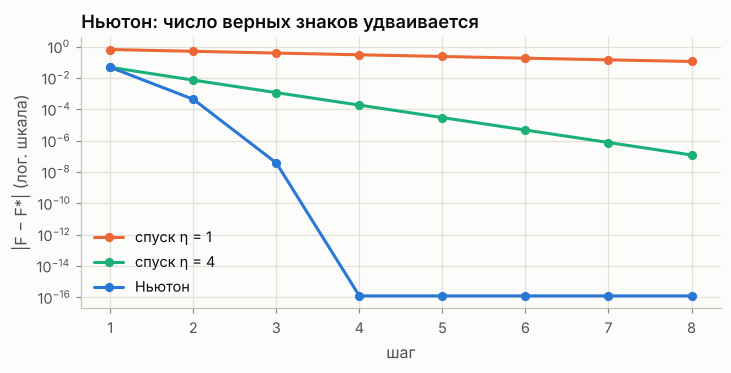

In [8]:
sigmoid = lambda z: 1 / (1 + np.exp(-z))  # noqa: E731
d1 = lambda F: sigmoid(F) - 0.3  # noqa: E731
d2 = lambda F: sigmoid(F) * (1 - sigmoid(F))  # noqa: E731
target = np.log(0.3 / 0.7)
fig, ax = plt.subplots(figsize=(7.5, 3.2))
for name, step, color in [("спуск η = 1", lambda F: F - d1(F), style.ORANGE),
                          ("спуск η = 4", lambda F: F - 4 * d1(F), style.AQUA),
                          ("Ньютон", lambda F: F - d1(F) / d2(F), style.BLUE)]:
    F, err = 0.0, []
    for _ in range(8):
        F = step(F)
        err.append(abs(F - target) + 1e-17)
    ax.semilogy(range(1, 9), err, marker="o", color=color, label=name)
    print(f"{name:12s}: {np.round(err[:4], 8)}")
ax.set(xlabel="шаг", ylabel="|F − F*| (лог. шкала)", title="Ньютон: число верных знаков удваивается")
ax.legend()
plt.show()

## 8. Спуск по прогнозам против бустинга

Параметры — прогнозы $F_i$ на 12 обучающих точках. Свободный спуск запоминает ответы; бустинг приближает шаг
деревом и обобщает на новые точки.

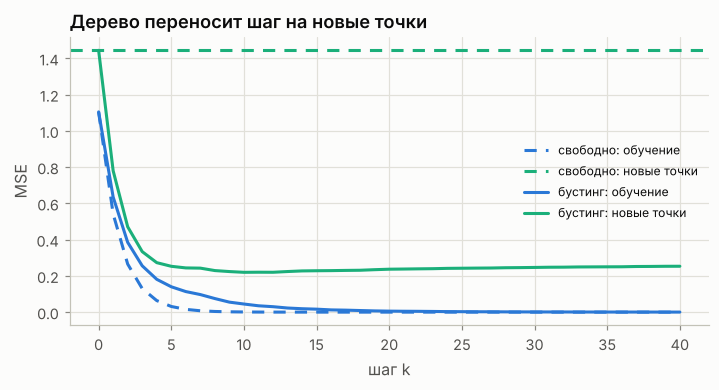

после 40 шагов: свободно — обучение 0.0000, новые 1.4441; бустинг — обучение 0.0002, новые 0.2531


In [9]:
X, yw = datasets.regression_1d(kind="wave", n=12, noise=0.3, seed=3)
Xt, yt = datasets.regression_1d(kind="wave", n=200, noise=0.3, seed=103)
nu, K = 0.3, 40
F = np.full_like(yw, yw.mean())
free_tr = [mse(yw, F)]
for _ in range(K):
    F = F + nu * (yw - F)
    free_tr.append(mse(yw, F))
gb = GBRegressor(n_estimators=K, learning_rate=nu, max_depth=2).fit(X, yw)
gb_tr = [mse(yw, gb.predict(X, n_iter=k)) for k in range(K + 1)]
gb_te = [mse(yt, gb.predict(Xt, n_iter=k)) for k in range(K + 1)]
free_te = mse(yt, np.full_like(yt, yw.mean()))

fig, ax = plt.subplots(figsize=(7.5, 3.4))
ax.plot(free_tr, color=style.ROLE["train"], ls=(0, (4, 3)), label="свободно: обучение")
ax.axhline(free_te, color=style.ROLE["test"], ls=(0, (4, 3)), label="свободно: новые точки")
ax.plot(gb_tr, color=style.ROLE["train"], label="бустинг: обучение")
ax.plot(gb_te, color=style.ROLE["test"], label="бустинг: новые точки")
ax.set(xlabel="шаг k", ylabel="MSE", title="Дерево переносит шаг на новые точки")
ax.legend(fontsize=8)
plt.show()
print(f"после {K} шагов: свободно — обучение {free_tr[-1]:.4f}, новые {free_te:.4f}; бустинг — обучение {gb_tr[-1]:.4f}, новые {gb_te[-1]:.4f}")

## Упражнения

1. $f(\theta) = (\theta - 3)^2$, $\theta_0 = 0$, $\eta = 0.25$: найдите $\theta_1, \theta_2, \theta_3$.
2. Для $\tfrac a2\theta^2$ выведите границу устойчивости и проверьте численно при $a = 3$.
3. В задаче о прямой (линейные данные, 30 точек) посчитайте число шагов до точности $10^{-4}$ для исходного
   и центрированного x.
4. Затухающий темп для $|\theta|$: сравните с постоянным.
5. Проверьте конечными разностями производную потерь Хьюбера.
6. Сравните спуск, спуск с «идеальным» темпом $1/f''(0)$ и Ньютон для log-loss константы с долей единиц 0.1.

<details><summary>Решения</summary>

`python lessons/lesson_1_3/exercises/solutions.py`
</details>